Khalid Waleed Alhilal
2230000788
8m02

# LAB6


### Import necessary libraries and setup helper function


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize

# Helper function provided in the lab manual 
def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    ph, pw = shape
    
    # Find the center coordinates
    cy, cx = ph // 2, pw // 2
    
    # Insert kernel centered at the img center
    padded[cy - kh//2 : cy - kh//2 + kh, cx - kw//2 : cx - kw//2 + kw] = kernel
    return padded

#### Task 1 - Sobel Filter in Frequency Domain
#### Task 1.1: Load Image and Define Sobel Kernels

In [3]:
# 1. Load and preprocess the image
image = data.camera()
image = resize(image, (256, 256))

# 2. Define Sobel kernels for edge detection
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

# 3. Center embed the Sobel kernels into the same size as the image
padded_sobel_x = center_embed_kernel(sobel_x, image.shape)
padded_sobel_y = center_embed_kernel(sobel_y, image.shape)

shifted_sobel_x = np.fft.ifftshift(padded_sobel_x)
shifted_sobel_y = np.fft.ifftshift(padded_sobel_y)

#### Task 1.2: Apply Fast Fourier Transform (FFT) and Filter

In [4]:
# 4. Compute the Fourier Transform of the image and the kernels
F_image = np.fft.fft2(image)
F_sobel_x = np.fft.fft2(shifted_sobel_x)
F_sobel_y = np.fft.fft2(shifted_sobel_y)

# 5. Perform element-wise multiplication in the frequency domain
Filtered_F_x = F_image * F_sobel_x
Filtered_F_y = F_image * F_sobel_y

#### Task 1.3: Inverse FFT and Plotting Results

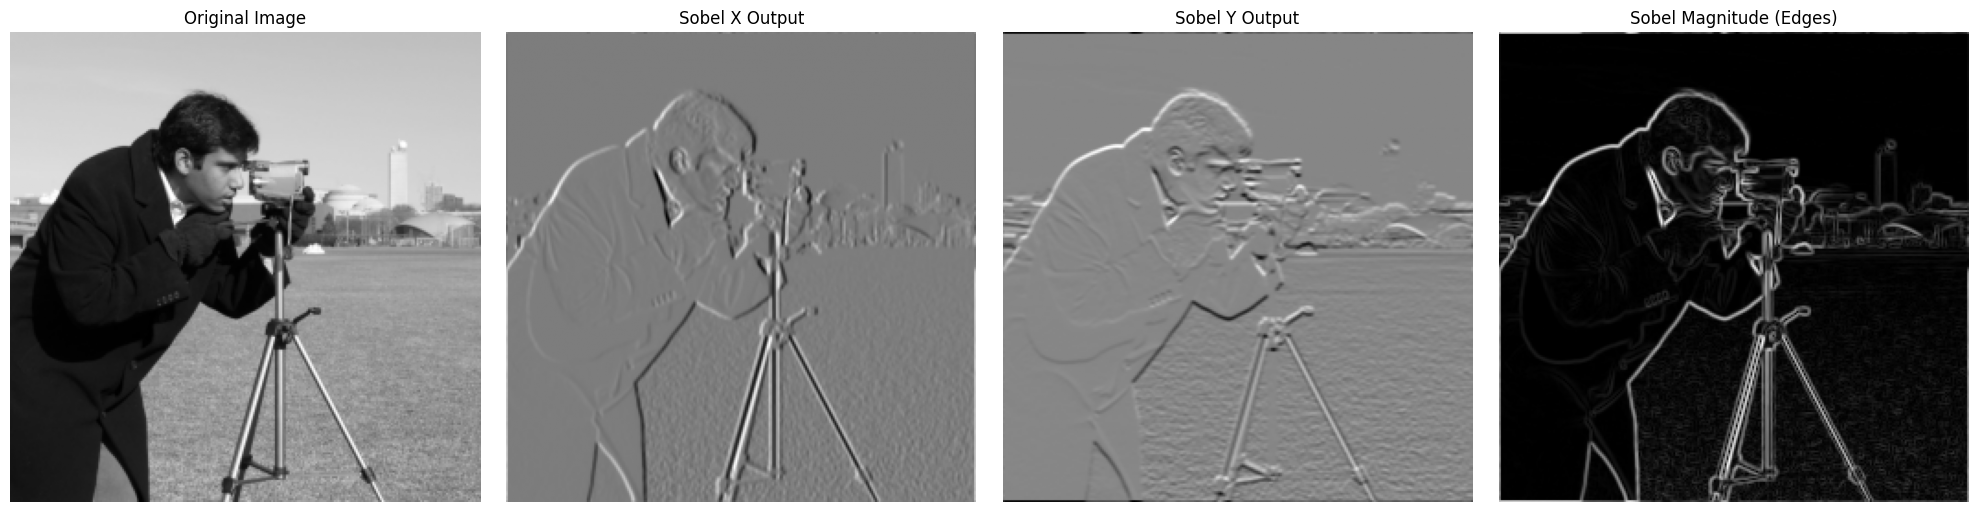

In [5]:
# 6. Compute the inverse FFT to get the filtered images in the spatial domain
filtered_x = np.real(np.fft.ifft2(Filtered_F_x))
filtered_y = np.real(np.fft.ifft2(Filtered_F_y))

# 7. Compute the magnitude of the Sobel response
sobel_magnitude = np.sqrt(filtered_x**2 + filtered_y**2)

# 8. Visualize the results
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(filtered_x, cmap='gray')
axes[1].set_title('Sobel X Output')
axes[1].axis('off')

axes[2].imshow(filtered_y, cmap='gray')
axes[2].set_title('Sobel Y Output')
axes[2].axis('off')

axes[3].imshow(sobel_magnitude, cmap='gray')
axes[3].set_title('Sobel Magnitude (Edges)')
axes[3].axis('off')

plt.tight_layout()
plt.show()